In [ ]:
!pip install tensorflow matplotlib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('oxford_iiit_pet', with_info=True)

train = dataset['train']
test = dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.RJI4JD_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.RJI4JD_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 128

def preprocess(data):
    img = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE))

    img = tf.cast(img, tf.float32) / 255.0

    # Convert to binary (pet vs background)
    mask = mask - 1
    mask = tf.cast(mask == 0, tf.float32)

    return img, mask

In [ ]:
BATCH_SIZE = 16

train_data = train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test.map(preprocess).batch(BATCH_SIZE)

In [ ]:
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = tf.keras.layers.MaxPooling2D()(f)
    return f, p

def decoder_block(x, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet():
    inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    s1, p1 = encoder_block(inputs, 16)
    s2, p2 = encoder_block(p1, 32)
    s3, p3 = encoder_block(p2, 64)

    # Bottleneck
    b = conv_block(p3, 128)

    # Decoder
    d1 = decoder_block(b, s3, 64)
    d2 = decoder_block(d1, s2, 32)
    d3 = decoder_block(d2, s1, 16)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(d3)

    return tf.keras.Model(inputs, outputs)

model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[

 Total params: 484,849 (1.85 MB)

 Trainable params: 483,441 (1.84 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7989 - loss: 0.4477 - val_accuracy: 0.7502 - val_loss: 0.4894
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.8756 - loss: 0.2948 - val_accuracy: 0.8546 - val_loss: 0.3734
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.8883 - loss: 0.2618 - val_accuracy: 0.8475 - val_loss: 0.4646
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.8993 - loss: 0.2372 - val_accuracy: 0.8797 - val_loss: 0.3072
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9040 - loss: 0.2267 - val_accuracy: 0.8740 - val_loss: 0.3321
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.9086 - loss: 0.2161 - val_accuracy: 0.9051 - val_loss: 0.2304
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.9157 - loss: 0.2001 - val_accuracy: 0.8861 - val_loss: 0.2680
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.9200 - loss: 0.1913 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


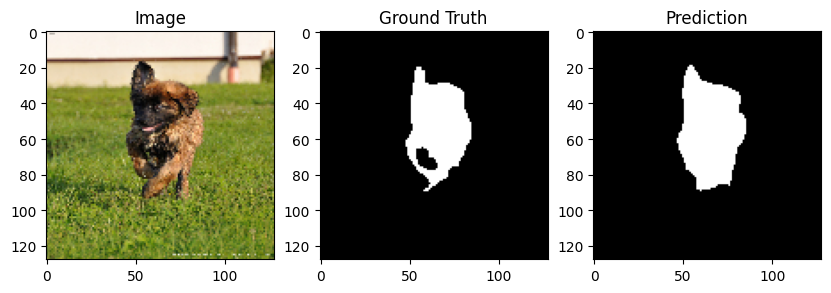

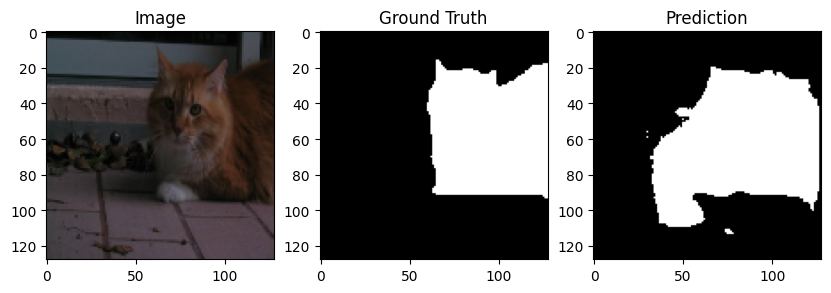

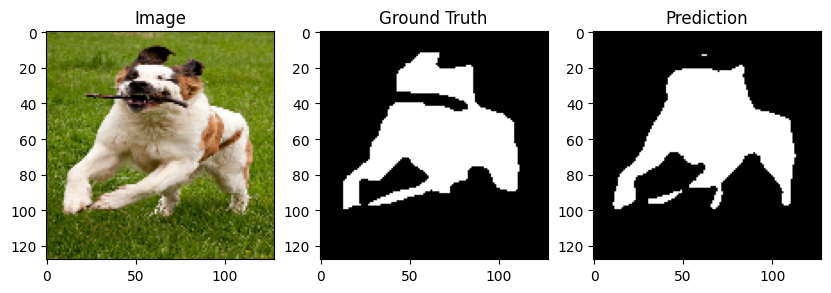

In [ ]:
def show_predictions(dataset, num=3):
    for img, mask in dataset.take(1):
        pred = model.predict(img)

        for i in range(num):
            plt.figure(figsize=(10,3))

            plt.subplot(1,3,1)
            plt.imshow(img[i])
            plt.title("Image")

            plt.subplot(1,3,2)
            plt.imshow(mask[i].numpy().squeeze(), cmap='gray')
            plt.title("Ground Truth")

            plt.subplot(1,3,3)
            plt.imshow(pred[i].squeeze() > 0.5, cmap='gray')
            plt.title("Prediction")

            plt.show()

show_predictions(test_data)

Saving images-2.jpeg to images-2.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


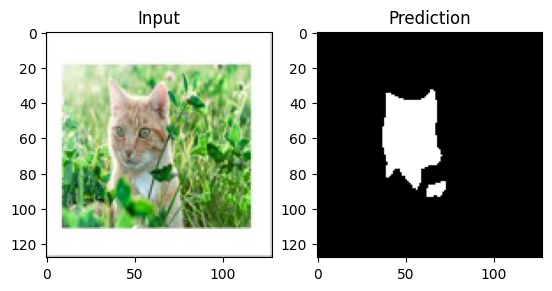

In [ ]:
from google.colab import files
uploaded = files.upload()

from PIL import Image

img = Image.open(list(uploaded.keys())[0]).resize((IMG_SIZE, IMG_SIZE))
img = np.array(img) / 255.0

pred = model.predict(np.expand_dims(img, axis=0))[0]

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(pred.squeeze() > 0.5, cmap='gray')
plt.title("Prediction")

plt.show()